# Predicted versus observed plot

This plot scatters the predicted value of each observation against its observed value, with the line of perfect prediction at forty five degrees — so how far a point sits from the line is how far the prediction missed. Points above the line were over-predicted, points below under-predicted, and the R squared in the corner gives the fraction of the variance accounted for.

    plot_predict_observations(observed, predicted; resp = 1, kwargs...)

The kernel PLS regression is the model this serves, through `plskern_predict`:

    plot_predict_observations(Y,     plskern_predict(m, X))         # the training fit
    plot_predict_observations(Ytest, plskern_predict(m, Xtest))     # a test set

The discriminant models predict a class rather than a value, so their fit is read from a confusion of the classes instead, and the decompositions predict nothing at all.

The frame is kept square with matched limits, so the diagonal really is at forty five degrees and the eye can judge the scatter against it — that is the whole point of the figure.

## Setup

In [1]:
using BigRiverEssence
using WolfRiverPlots
using Plots
using StableRNGs


## A simulated example

A response built from the predictors plus noise, so the model has a real signal to fit and the points fall near — but not on — the line. Three responses, since a PLS regression can predict several at once and the plot draws one at a time.

We split the observations in two. The training half sets the coefficients, and the test half is held back, which is what lets us compare an honest fit against a flattering one further down.

In [2]:
rng = StableRNG(20240801)

n = 120    # observations
p = 15     # predictors
q = 3      # responses

Xall = randn(rng, n, p)
B    = randn(rng, p, q)
Yall = Xall * B .+ 0.5 .* randn(rng, n, q)

# hold half the observations back
tr = 1:60
te = 61:120

Xtr, Ytr = Xall[tr, :], Yall[tr, :]
Xte, Yte = Xall[te, :], Yall[te, :]

m = plskern(Xtr, Ytr; nlv = 5)

size(Ytr), size(Yte)

((60, 3), (60, 3))

## The default plot

Given the observed and predicted matrices, we get the first response, the diagonal, and the R squared. This is the **training** fit — the same observations that set the coefficients, now predicted by them — so the points hug the line closely.

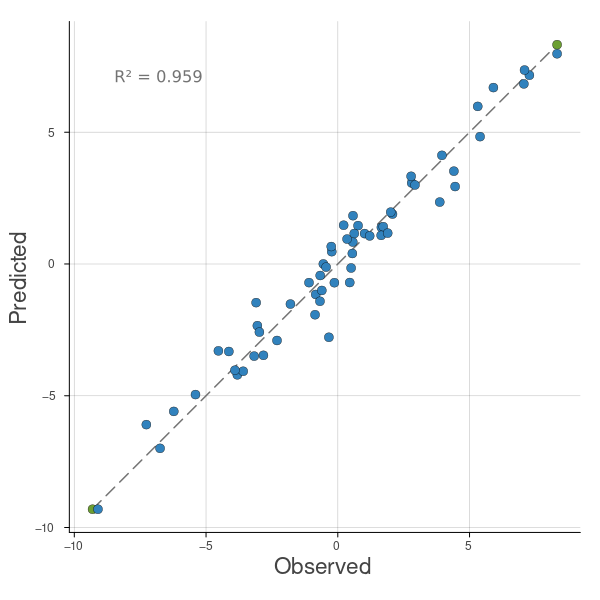

In [3]:
plot_predict_observations(Ytr, plskern_predict(m, Xtr))

---

# Modifying the plot

Only one argument changes what we draw: `resp` picks the response column, since a regression of several responses is drawn one at a time. Everything else is styling — `pointcolor` and `linecolor_` for the two layers, `refline` and `showr2` to remove either of them, and the standard attributes on top.

The trailing underscore on `linecolor_` is deliberate. `linecolor` is a standard `Plots` attribute, so the bare name would be intercepted before it reached us — the same reason the scree plot spells it that way.

## The honest fit

The same model against the held-back half. The scatter is wider and the R squared lower, because these observations had no hand in setting the coefficients — this is the error the model would make on data it has not seen, and it is the version worth reporting.

If a test plot ever looks as tight as its training plot, something has leaked between the two halves.

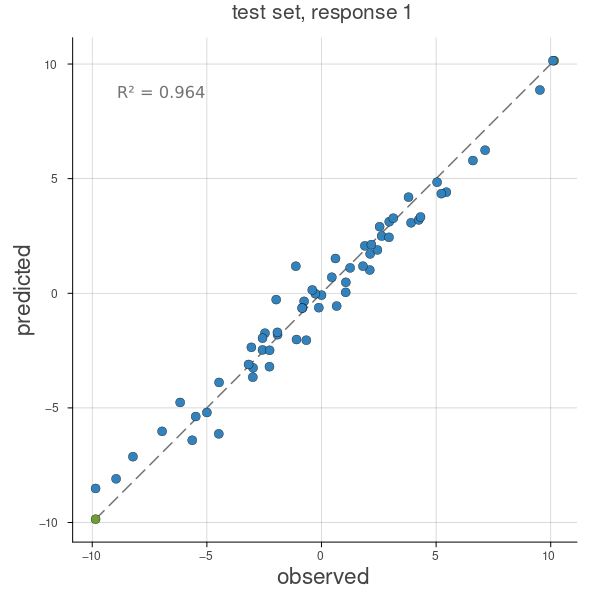

In [4]:
plot_predict_observations(Yte, plskern_predict(m, Xte);
                          xlabel = "observed",
                          ylabel = "predicted",
                          title  = "test set, response 1")

## A different response

`resp` draws another column of the response matrix. The three responses were built with independent coefficients, so each is fitted with its own accuracy and the R squared differs between them — worth checking each rather than reporting the first and assuming the rest follow.

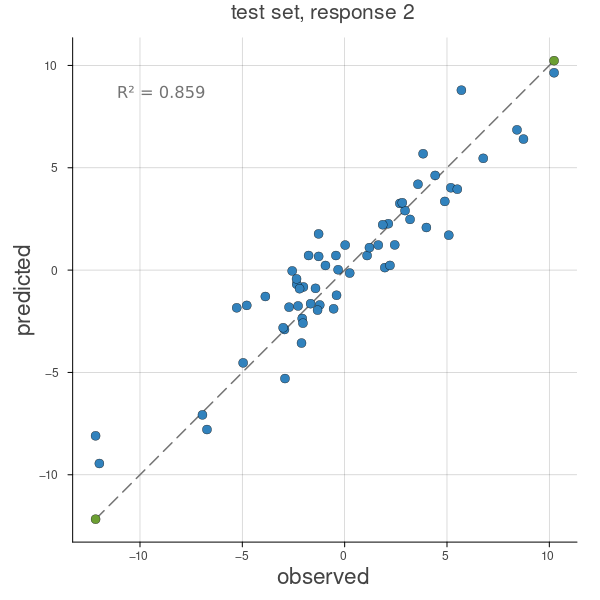

In [5]:
plot_predict_observations(Yte, plskern_predict(m, Xte);
                          resp   = 2,
                          xlabel = "observed",
                          ylabel = "predicted",
                          title  = "test set, response 2")

## Colors, and stripping it back

`pointcolor` sets the scatter and `linecolor_` the diagonal. Both `refline = false` and `showr2 = false` remove their layer entirely — worth doing when the figure sits in a panel whose caption already carries the R squared, or when several fits are being compared and only the scatter should differ.

The square frame is a default like any other, so `aspect_ratio = :none` releases it if the response has a range that makes a square frame wasteful.

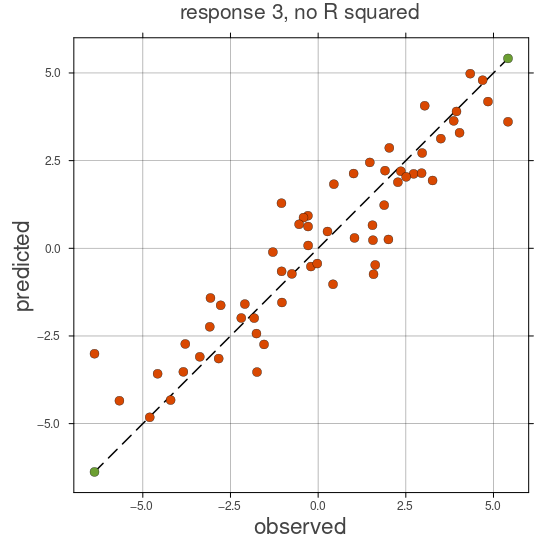

In [6]:
plot_predict_observations(Yte, plskern_predict(m, Xte);
                          resp       = 3,
                          pointcolor = "#d94801",
                          linecolor_ = :black,
                          showr2     = false,
                          xlabel     = "observed",
                          ylabel     = "predicted",
                          title      = "response 3, no R squared",
                          markersize = 5,
                          size       = (550, 550))